#M505 INTRO TO AI & MACHINE LEARNING

##A pipeline that does:** Mushroom Classification: Edible vs Poisonous**

#Dataset:https://www.kaggle.com/datasets/uciml/mushroom-classification



##By: Binta Antony GH1053998


#PROBLEM STATEMENT
As a newly appointed data scientist in a food safety office that ensures safe and edible supply of mushrooms to consumers,the major task is to to automate the classification of mushrooms into edible and poisonous categories using their physical characteristics.

The solution to this problem will enable the organization to enhance food safety standards while decreasing their need for manual inspections as well as reducing their operational hazards and improving their efficiency.
As a reliable machine learning model it could support faster screening and reduce the workloads and helps in identifying the posisonous mushrooms will help to avoid critical conditions.


The data is collected through
* Observations
* Labels identified by mycologists
* Physical features like colour,odor,shape,gill sizes,habitat etc

This task is a supervised binary classification and the target =class
* e-->edible
* b-->poisonous




#DATA COLLECTION

Initially importing all python libraries and the dataset is loaded

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")


In [23]:
df = pd.read_csv("/content/mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


#DATA EXPLORATION
Here the basic explorations are made like:

* Shape,
* Data types,
* Missing values,
* Duplicates,
* Target balance.


In [24]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (8124, 23)

Data types:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object


In [25]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Missing Count", ascending=False)

missing_summary.head(10)

,Missing Count,Missing %
class,0,0.0
cap-shape,0,0.0
cap-surface,0,0.0
cap-color,0,0.0
bruises,0,0.0
odor,0,0.0
gill-attachment,0,0.0
gill-spacing,0,0.0
gill-size,0,0.0
gill-color,0,0.0


In [26]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [27]:
target_counts = df["class"].value_counts()
target_props = df["class"].value_counts(normalize=True).round(3)

print("Target counts:\n", target_counts)
print("\nTarget proportions:\n", target_props)

Target counts:
 class
e    4208
p    3916
Name: count, dtype: int64

Target proportions:
 class
e    0.518
p    0.482
Name: proportion, dtype: float64


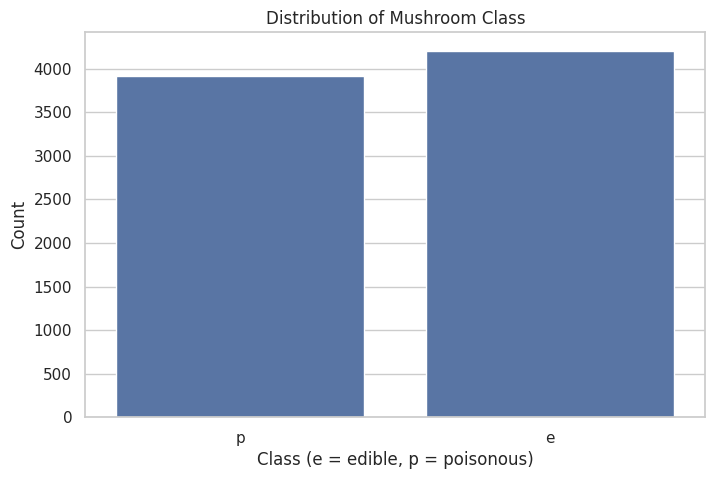

In [28]:
sns.countplot(data=df, x="class")
plt.title("Distribution of Mushroom Class")
plt.xlabel("Class (e = edible, p = poisonous)")
plt.ylabel("Count")
plt.show()

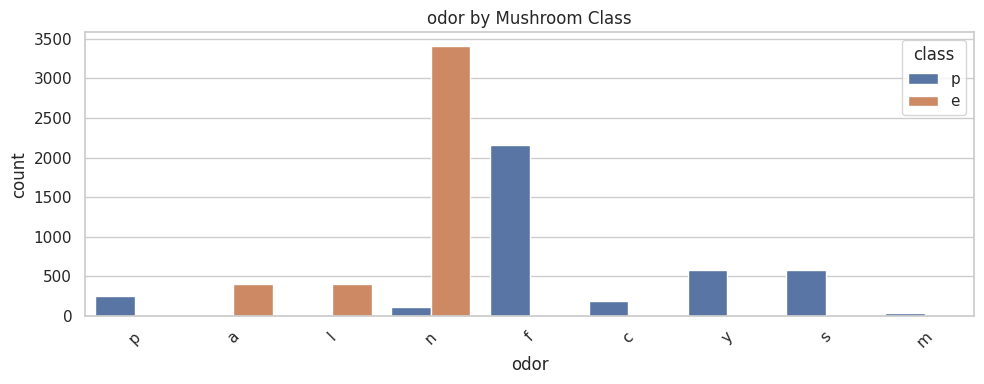

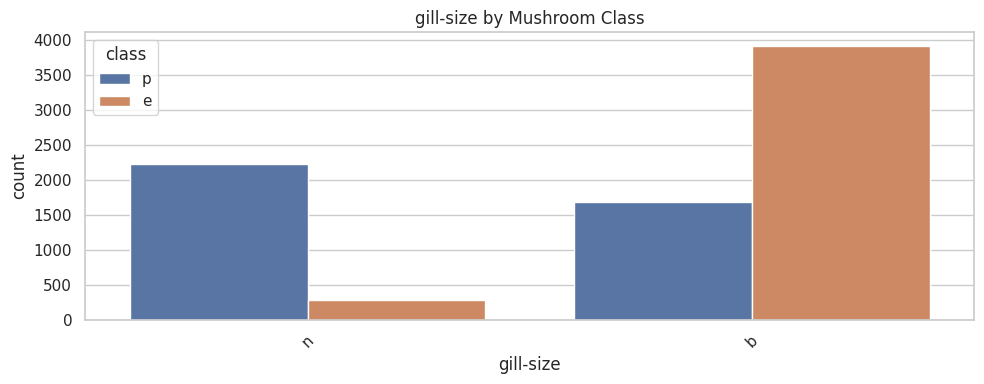

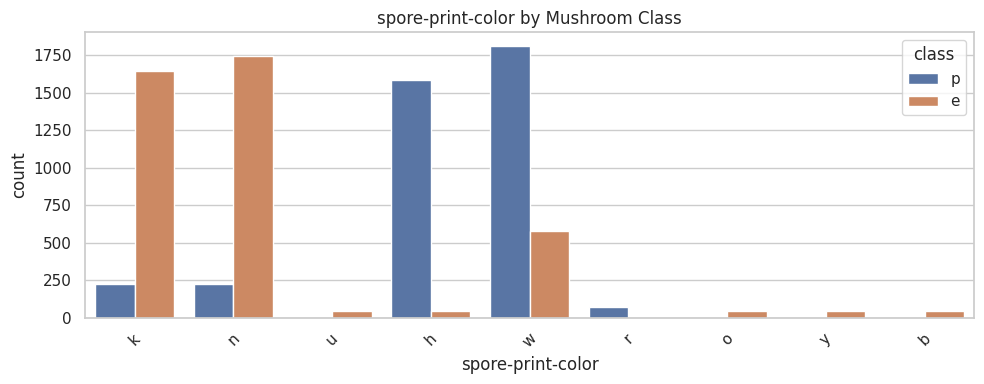

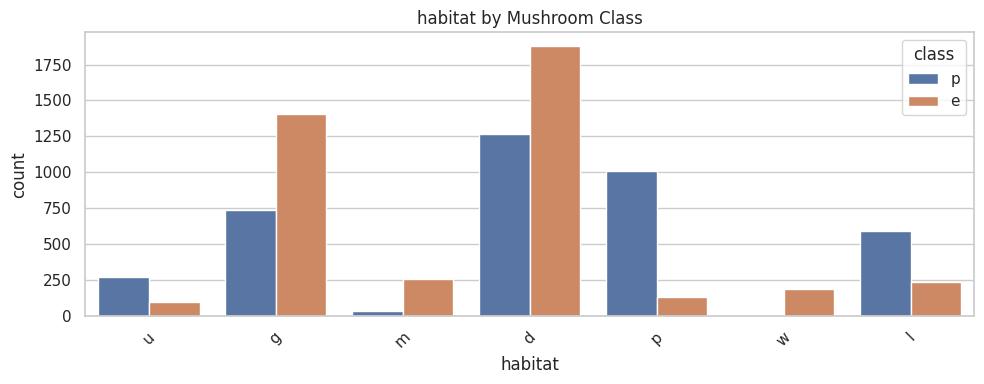

In [29]:
sample_cols = ["odor", "gill-size", "spore-print-color", "habitat"]

for col in sample_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="class")
    plt.title(f"{col} by Mushroom Class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#DATA PRE-PROCESSING
The data was allowed to check the presence of any missing values & replacements are done where it was necessary.
The dataset is  further splited into training and testing sets

In [30]:
df = df.replace("?", np.nan)

pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Missing Count", ascending=False).head(10)

,Missing Count,Missing %
stalk-root,2480,30.53
cap-shape,0,0.00
class,0,0.00
cap-color,0,0.00
bruises,0,0.00
odor,0,0.00
cap-surface,0,0.00
gill-attachment,0,0.00
gill-spacing,0,0.00
gill-color,0,0.00


In [31]:
df["class"] = df["class"].map({"e": 0, "p": 1})

X = df.drop("class", axis=1)
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nEncoded target distribution:")
print(y.value_counts())

X shape: (8124, 22)
y shape: (8124,)

Encoded target distribution:
class
0    4208
1    3916
Name: count, dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (6499, 22) (6499,)
Testing set: (1625, 22) (1625,)


#FEATURE ENGINEERING
The dataset is entirely having categorical features and it is to be converted to numerical form hence One-hot encoder is used.
It converts categorical features to binary columns for the model to get understand

In [33]:
categorical_features = X_train.columns.tolist()

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cap-shape', 'cap-surface', 'cap-color',
                                  'bruises', 'odor', 'gill-attachment',
                                  'gill-spacing', 'gill-size', 'gill-color',
                                  'stalk-shape', 'stalk-root',
                                  'stalk-surface-above-ring',
                                  'stalk-surface-below-ring',
                                  'stalk-color-above-ring',
                                  'stalk-color-below-ring', 'veil-type',
                                  'veil-color', 'ring-number', 'ring-type',
                                  'spore-print-color', 'population',
                                  'habitat'])])

#MODEL TRAINING & HYPERPARAMETER TUNING

Three modes are choosed inorder to provide a comprehensive comparison between
a simple linear model,bagging based ensamble model,boosting based ensamble model.The used models are:
* Logistic Regression
* Random Forest
* Gradient boosting




For hyperparameter tuning GridSearchCV is used to find the best combination of hyperparameters for the model.It does that  by testing multiple parameter values using cross-validation.

 Training the model and tuning the hyperparameter were exclusively performed
 on the training data using cross-validation inorder to avoid data leakage.
 Based on the cross-validation performance the best performing model is selected and thus it is evaluvated on the test data tp asses its ability


We use:
- **Stratified 5-fold cross-validation**
- **F1-score** for model comparison
- **GridSearchCV** for hyperparameter tuning


Cross validation is performed by dividing the data into 5 chunks and allowed to maintain class balance in each fold/chunks thus to give accurate estimate of model performance.

The model with the highest cross-validated F1-score will be selected for final test evaluation on the unseen data.


In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "Logistic Regression": (
        Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__solver": ["lbfgs", "liblinear"]
        }
    ),

    "Random Forest": (
        Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5]
        }
    ),

    "Gradient Boosting": (
        Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 150],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    )
}

cv_results = []
best_estimators = {}

for model_name, (pipeline, param_grid) in search_spaces.items():
    print(f"Running GridSearchCV for: {model_name}")

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_estimators[model_name] = grid.best_estimator_

    cv_results.append({
        "Model": model_name,
        "Best Params": grid.best_params_,
        "Best CV F1": round(grid.best_score_, 4)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Best CV F1", ascending=False).reset_index(drop=True)
cv_results_df

Running GridSearchCV for: Logistic Regression
Running GridSearchCV for: Random Forest
Running GridSearchCV for: Gradient Boosting


,Model,Best Params,Best CV F1
0,Random Forest,"{'model__max_depth': None, 'model__min_samples...",1.0000
1,Logistic Regression,"{'model__C': 10, 'model__solver': 'lbfgs'}",0.9997
2,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.9997


In [35]:
best_model_name = cv_results_df.loc[0, "Model"]
best_model = best_estimators[best_model_name]

print("Best model selected:", best_model_name)
best_model

Best model selected: Random Forest


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cap-shape', 'cap-surface',
                                                   'cap-color', 'bruises',
                                                   'odor', 'gill-attachment',
                                                   'gill-spacing', 'gill-size',
                                                   'gill-color', 'stalk-shape',
                                                   'stalk-root',
                                                   'stalk-surface-above-ring',
                                                   'stalk-surface-below-ring',
                                                   'stalk-color-above-ring',
                                                   'stalk-color-below-ring',
                                                   'veil-type', 'veil-color',
                                                   'ring-number', 'ring-type',
                                                   'spore-print-color',
                                                   'population',
                                                   'habitat'])])),
                ('model', RandomForestClassifier(random_state=42))])

From the above Random Forest is the best model ranked as one since it shows a bit slighter increased value from the others

#MODEL EVALUVATION
Random Forest being the best model is allowed to evaluvate the test data thus performance scores are generated,the main metrics are:
* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC

 Recall is important for identifying the poisonus mushroom

In [36]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [test_accuracy, test_precision, test_recall, test_f1, test_auc]
})

metrics_df

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0
4,ROC-AUC,1.0


Classification Report & Confusion Matrix are geneated

In [37]:
print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



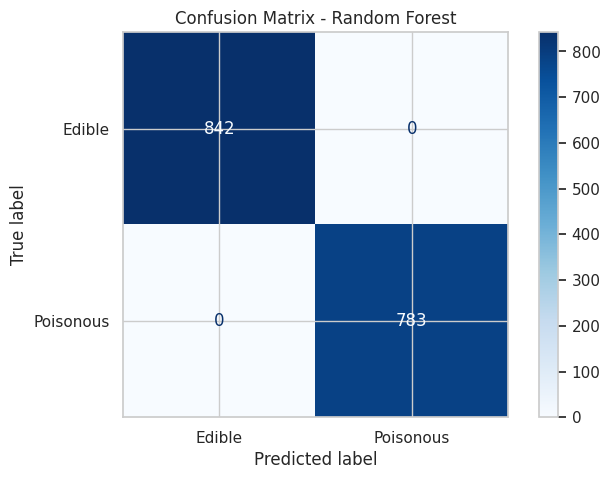

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Edible", "Poisonous"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

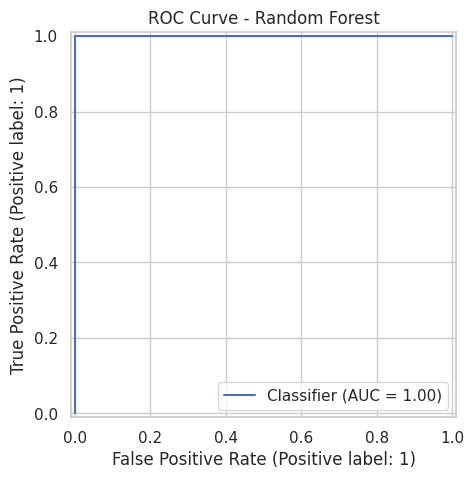

In [39]:
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Curve - {best_model_name}")
    plt.show()


Permutation importance is used to identify which feature contributed the most


In [40]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
4,odor,0.018351
7,gill-size,0.008892
19,spore-print-color,0.003333
2,cap-color,0.000000
1,cap-surface,0.000000
0,cap-shape,0.000000
5,gill-attachment,0.000000
3,bruises,0.000000
8,gill-color,0.000000
6,gill-spacing,0.000000


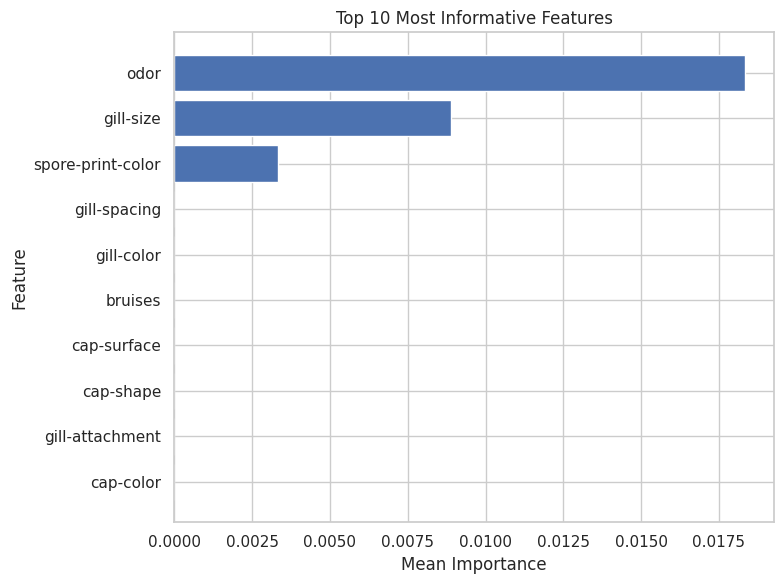

In [41]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Most Informative Features")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#OVERALL MODEL DISCUSSION



The proposed machine learning pipeline demonstrates strong performance due to the use of clean and well structured data with a good balancing.The specified features in the dataset enabled the model to gain an excellent classification.

Implication of this pipeline ensures data leakage at any cost is avoided and the comprehensive comparisons among the models provide a robust evaluvation.










##Limitations
Although it is a good evaluvation there exists some limiations too.The dataset is not included with all the mushroom species, and the model’s predictions rely heavily on accurate feature observation.


#CONCLUSION


 From a business perspective, the model can significantly enhance food safety operations by fastening up screening processes, reducing manual workload, and thereby supporting in decision-making by flagging high-risk cases.

 The better recommendation is to use this model as a screening assistant to prioritize high recall for poisonous mushrooms, and also including the involvement of  human experts for uncertain predictions.



The model is reasonably explainable because:
* Major features are identified which influences prediction
* Result of the analysis could be even understand to non-technicals

The model is suitable for deployment as a tool in supporting the decision making.
